# Clustering Method Comparison — Mean-Pooled Embeddings

Runs all four clustering methods from `cluster_alts.py` on the pre-computed
`mean_pooled_embeddings.pkl` file and visualizes each result with t-SNE.

Clustering Algorithms Used:
1. Fuzzy K-Means
2. Spectral Clustering
3. DBSCAN
4. GMM

### Step 1: Setup (drive mounting, paths)

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE_BASE           = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data/calced_embeddings"
PROJECT_BASE         = "/content/drive/MyDrive/S2026/CS 274/Playlist-Recommender"
EMBEDDINGS_PKL       = f"{DRIVE_BASE}/mean_pooled_embeddings.pkl"
CLUSTERS_OUTPUT_DIR  = f"{PROJECT_BASE}/new clusters"
REPO_DIR             = "/content/RecsysUpgrade"

os.makedirs(CLUSTERS_OUTPUT_DIR, exist_ok=True)
print("Paths configured.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


### Step 2: Clone repo, install requirements.txt and import `cluster_alts`

In [3]:
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/siddmohanty111/RecsysUpgrade.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

print("Repo ready:", REPO_DIR)


Cloning into '/content/RecsysUpgrade'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 65 (delta 30), reused 47 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 748.82 KiB | 13.61 MiB/s, done.
Resolving deltas: 100% (30/30), done.
Repo ready: /content/RecsysUpgrade


In [4]:
%pip install -r {REPO_DIR}/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.9/515.9 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
ERROR: pip's depend

#### All imports here

In [5]:
import os
import random
import importlib.util
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skfuzzy import cmeans
from sklearn.manifold import TSNE


In [6]:
cluster_alts_path = os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "cluster_alts.py")

with open(cluster_alts_path, 'r') as f:
    content = f.read()

# Replace the incorrect import statement
content = content.replace('from skfuzzy import cmeans, cmeans_predict', 'import skfuzzy as fuzz')

# Replace function calls
content = content.replace('cmeans(', 'fuzz.cmeans(')
content = content.replace('cmeans_predict(', 'fuzz.cmeans_predict(')

with open(cluster_alts_path, 'w') as f:
    f.write(content)

print(f"Successfully modified {cluster_alts_path} to correct skfuzzy imports.")


Successfully modified /content/RecsysUpgrade/PlaylistRecsysUpgrade/clustering/cluster_alts.py to correct skfuzzy imports.


In [7]:
spec = importlib.util.spec_from_file_location(
    "cluster_alts",
    os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "cluster_alts.py"),
)
cluster_alts = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cluster_alts)

print("cluster_alts loaded.")


cluster_alts loaded.


### Step 3 — Load embeddings

In [8]:
with open(EMBEDDINGS_PKL, 'rb') as f:
    data = pickle.load(f)

# Support both a raw dict (pid -> vector) and the structured dict used by other pipeline scripts
if isinstance(data, dict) and 'playlist_embeddings' in data:
    playlist_embeddings = data['playlist_embeddings']
    playlist_titles     = data.get('playlist_titles', {})
    playlist_tracks     = data.get('playlist_tracks', {})
else:
    # Assume the file is directly a pid -> embedding dict
    playlist_embeddings = data
    playlist_titles     = {}
    playlist_tracks     = {}

embedding_matrix = np.array(list(playlist_embeddings.values()))
pids = list(playlist_embeddings.keys())

print(f"Loaded {len(pids)} playlists, embedding dim = {embedding_matrix.shape[1]}")


Loaded 1000001 playlists, embedding dim = 768


### Step 4: Configuration

The 50k sample was supposed to be used when I was trying DBSCAN and Spectral, but I abandoned this idea (for now?) so the cluster sample ends up not being used. FKM is pretty fast on the entire 1m dataset, so don't create a sample if re-running this.

In [9]:
CLUSTER_OPTIONS = [50, 100, 200]
# after trials, it looks like FKM continues to select ~50 clusters, even when we ask for more (remaining 150 clusters have low memberships and end up not getting represented when we apply argmax selection)
NUM_CLUSTERS = 50

CLUSTER_SAMPLE = min(50_000, len(pids))

print("Sampling data for faster clustering...")
random.seed(42)
sampled_pids = random.sample(pids, CLUSTER_SAMPLE)

sampled_playlist_embeddings = {pid: playlist_embeddings[pid] for pid in sampled_pids}
sampled_playlist_titles = {pid: playlist_titles.get(pid, "") for pid in sampled_pids}
sampled_playlist_tracks = {pid: playlist_tracks.get(pid, []) for pid in sampled_pids}

sampled_embedding_matrix = np.array([sampled_playlist_embeddings[pid] for pid in sampled_pids])

# t-SNE sample size — reduce if the full dataset is too large
TSNE_SAMPLE = min(5000, len(sampled_pids))

print(f"Clustering into {NUM_CLUSTERS} clusters (using the first value from NUM_CLUSTERS list) on a sample of {CLUSTER_SAMPLE} playlists.\nt-SNE on {TSNE_SAMPLE} playlists.")


Sampling data for faster clustering...
Clustering into 50 clusters (using the first value from NUM_CLUSTERS list) on a sample of 50000 playlists.
t-SNE on 5000 playlists.


### Step 5: Fuzzy K-Means

In [10]:
fkmeans_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_clusters.csv")

print("Fitting Fuzzy K-Means...")
fkm_result = cmeans(embedding_matrix.T, NUM_CLUSTERS, 2, error=0.005, maxiter=1000)
fkmeans_labels = np.argmax(fkm_result[1], axis=0)

pd.DataFrame({
    'pid': pids,
    'cluster': fkmeans_labels
}).to_csv(fkmeans_output, index=False)

# Save cluster memberships for each pid to csv

fkmeans_memberships_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_memberships.csv")
pd.DataFrame(fkm_result[1].T, columns=[f"cluster_{i}" for i in range(NUM_CLUSTERS)]).to_csv(fkmeans_memberships_output, index=False)

print(f"Fuzzy K-Means done. Results saved to {fkmeans_output}")


Fitting Fuzzy K-Means...
Fuzzy K-Means done. Results saved to /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/new clusters/fkmeans_clusters.csv


### Step 6: t-SNE

In [11]:
# To keep complexity low for visualization, we will run t-SNE on a sample.
# The clustering (e.g., Fuzzy K-Means) is still performed on the full dataset.

# Use the sampled_embedding_matrix for t-SNE visualization
# sample_idx should be generated here to correspond to the points actually used for t-SNE
rng = np.random.default_rng(42)
sample_idx_tsne = rng.choice(len(pids), size=20000, replace=False)
tsne_input_matrix = embedding_matrix[sample_idx_tsne]
tsne_data_size = 20000

print(f"Running t-SNE on {tsne_data_size} sampled playlists...")
# n_jobs=-1 uses all available CPU cores
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
tsne_coords = tsne.fit_transform(tsne_input_matrix)
print("t-SNE complete.")

# The sample_idx for plotting should now reference the original position of the sampled data
# This means we need the labels corresponding to the sampled PIDs used for t-SNE
# For fkmeans, we ran it on the full data, so we need to map those full labels to our t-SNE sample.
# However, it's simpler to just ensure fkmeans_labels are consistent with sampled_pids,
# or re-run fkmeans on sampled_embedding_matrix if we want a 1:1 visualization of sampled clusters.
# For now, let's keep fkmeans_labels from the full dataset and pick the relevant ones for the t-SNE sample.


Running t-SNE on 20000 sampled playlists...
t-SNE complete.


### Step 7: Visualization

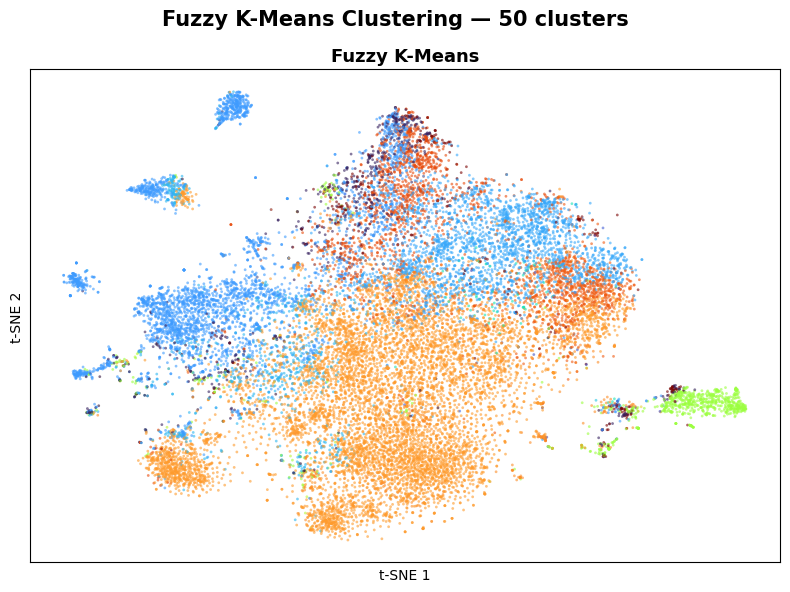

Plot saved.


In [12]:
# Simplify label mapping: directly index the original labels array with the t-SNE sample indices
fkmeans_labels_for_tsne_sample = fkmeans_labels[sample_idx_tsne]

methods = {
    "Fuzzy K-Means": fkmeans_labels_for_tsne_sample,
}

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Extract the single method and its labels
title, labels = list(methods.items())[0]

# Separate noise points (for DBSCAN compatibility, though fkmeans doesn't output -1)
noise_mask = (labels == -1)
cluster_mask = (labels != -1)

# Plot noise as grey
if noise_mask.any():
    ax.scatter(tsne_coords[noise_mask, 0], tsne_coords[noise_mask, 1],
               c='lightgrey', s=4, alpha=0.6, linewidths=0, label='Noise')

# Plot actual clusters using a continuous colormap ('turbo') that handles many clusters better than 'tab20'
ax.scatter(tsne_coords[cluster_mask, 0], tsne_coords[cluster_mask, 1],
           c=labels[cluster_mask], cmap='turbo', s=4, alpha=0.6, linewidths=0)

ax.set_title(title, fontsize=13, fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([])
ax.set_yticks([])

fig.suptitle(f"{title} Clustering — {NUM_CLUSTERS} clusters",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CLUSTERS_OUTPUT_DIR, "clustering_comparison_tsne.png"), dpi=150)
plt.show()
print("Plot saved.")


In [13]:
# The number of colors mapped by matplotlib equals the number of unique labels passed to `c=`
unique_clusters_in_sample = np.unique(labels[cluster_mask])
num_colors_in_plot = len(unique_clusters_in_sample)

print(f"Number of unique clusters (colors) plotted in the t-SNE sample: {num_colors_in_plot}")

# Let's also check how many unique clusters the full algorithm actually produced
unique_clusters_full = np.unique(fkmeans_labels)
print(f"Number of unique clusters found in the FULL dataset: {len(unique_clusters_full)}")


Number of unique clusters (colors) plotted in the t-SNE sample: 27
Number of unique clusters found in the FULL dataset: 35


### Step 8: Prune clusters

Perform LSH on the remaining clusters to see if there are any that should be removed for being too broad.

In [14]:
# Loading module

spec = importlib.util.spec_from_file_location(
    "lsh_cluster_picking",
    os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "lsh_cluster_picking.py"),
)
lsh_cluster_picking = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lsh_cluster_picking)

print("lsh_cluster_picking loaded.")

lsh_cluster_picking loaded.


#### Load the cluster labels and the cluster membership csv

In [17]:
try:
    CLUSTERS_OUTPUT_DIR
except NameError:
    PROJECT_BASE        = "/content/drive/MyDrive/S2026/CS 274/Playlist-Recommender"
    DRIVE_BASE          = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data/calced_embeddings"
    CLUSTERS_OUTPUT_DIR = f"{PROJECT_BASE}/new clusters"
    EMBEDDINGS_PKL      = f"{DRIVE_BASE}/mean_pooled_embeddings.pkl"

# Load hard cluster label assignments
cluster_assignments_df = pd.read_csv(os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_clusters.csv"), dtype={'pid': str})
print(f"Cluster labels loaded: {len(cluster_assignments_df)} playlists across {cluster_assignments_df['cluster'].nunique()} clusters.")

# Load soft FKM membership matrix  (rows = playlists, cols = cluster_0 … cluster_N)
fkm_membership_matrix = pd.read_csv(os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_memberships.csv")).values
print(f"FKM membership matrix loaded: shape {fkm_membership_matrix.shape}")

Cluster labels loaded: 1000001 playlists across 35 clusters.
FKM membership matrix loaded: shape (1000001, 50)


In [18]:
# Load the original embeddings and align rows to match cluster_assignments_df pid order.
# This is needed even when loading from CSVs because prune_clusters requires the embedding vectors.
with open(EMBEDDINGS_PKL, "rb") as f:
    raw_data = pickle.load(f)

playlist_embeddings_raw = (
    raw_data["playlist_embeddings"]
    if isinstance(raw_data, dict) and "playlist_embeddings" in raw_data
    else raw_data
)

pids_ordered     = cluster_assignments_df["pid"].tolist()
embedding_matrix = np.array([playlist_embeddings_raw[pid] for pid in pids_ordered])
print(f"Embeddings loaded and row-aligned with cluster assignments: {embedding_matrix.shape}")


Embeddings loaded and row-aligned with cluster assignments: (1000001, 768)


#### Run LSH pruning

In [19]:
# Reload module if not already in scope (e.g. when skipping earlier cells)
try:
    lsh_cluster_picking
except NameError:
    try:
        REPO_DIR
    except NameError:
        REPO_DIR = "/content/RecsysUpgrade"
    spec = importlib.util.spec_from_file_location(
        "lsh_cluster_picking",
        os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "lsh_cluster_picking.py"),
    )
    lsh_cluster_picking = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(lsh_cluster_picking)
    print("lsh_cluster_picking loaded.")

NUM_CLUSTERS = cluster_assignments_df["cluster"].nunique()

kept_clusters, kept_pids = lsh_cluster_picking.prune_clusters(
    embedding_matrix,
    cluster_assignments_df,
    threshold_percent=0.02,
)

print(f"\nClusters kept  : {len(kept_clusters)} / {NUM_CLUSTERS}")
print(f"Playlists kept : {len(kept_pids)}")

# Persist pruned assignments for downstream use
pruned_df = cluster_assignments_df[cluster_assignments_df["cluster"].isin(kept_clusters)]
pruned_output = os.path.join(CLUSTERS_OUTPUT_DIR, "fkmeans_clusters_pruned.csv")
pruned_df.to_csv(pruned_output, index=False)
print(f"Pruned cluster assignments saved to {pruned_output}")


Keeping cluster 1 (Max Bucket: 13.33% of playlists). 30 playlists in cluster.
Keeping cluster 2 (Max Bucket: 16.67% of playlists). 6 playlists in cluster.
Dropping cluster 3 (Max Bucket: 1.26% of playlists). 3504 playlists in cluster.
Dropping cluster 4 (Max Bucket: 1.54% of playlists). 26292 playlists in cluster.
Keeping cluster 5 (Max Bucket: 8.82% of playlists). 34 playlists in cluster.
Keeping cluster 6 (Max Bucket: 3.85% of playlists). 26 playlists in cluster.
Dropping cluster 7 (Max Bucket: 1.92% of playlists). 1352 playlists in cluster.
Keeping cluster 8 (Max Bucket: 2.02% of playlists). 347 playlists in cluster.
Keeping cluster 9 (Max Bucket: 4.29% of playlists). 303 playlists in cluster.
Keeping cluster 10 (Max Bucket: 3.57% of playlists). 56 playlists in cluster.
Dropping cluster 12 (Max Bucket: 1.85% of playlists). 173744 playlists in cluster.
Keeping cluster 13 (Max Bucket: 2.08% of playlists). 128340 playlists in cluster.
Dropping cluster 14 (Max Bucket: 1.68% of playlists

### Step 9: t-SNE on pruned clusters

Running t-SNE on 20000 playlists from 25 pruned clusters...
t-SNE complete.


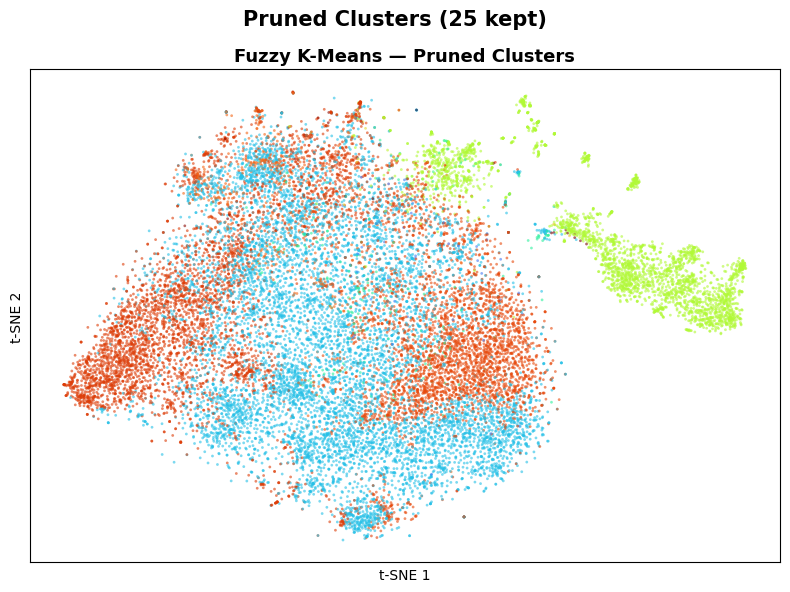

Plot saved.


In [20]:
# Build an index from pid -> row position in embedding_matrix so we can look up pruned pids quickly
pid_to_idx = {pid: i for i, pid in enumerate(pids_ordered)}

pruned_pids_list   = pruned_df["pid"].tolist()
pruned_labels      = pruned_df["cluster"].values
pruned_row_indices = np.array([pid_to_idx[pid] for pid in pruned_pids_list])
pruned_embeddings  = embedding_matrix[pruned_row_indices]

# Sub-sample for t-SNE if the pruned set is large
TSNE_PRUNED_SAMPLE = min(20_000, len(pruned_pids_list))
rng = np.random.default_rng(42)
tsne_pruned_idx    = rng.choice(len(pruned_pids_list), size=TSNE_PRUNED_SAMPLE, replace=False)

pruned_tsne_input  = pruned_embeddings[tsne_pruned_idx]
pruned_tsne_labels = pruned_labels[tsne_pruned_idx]

print(f"Running t-SNE on {TSNE_PRUNED_SAMPLE} playlists from {len(kept_clusters)} pruned clusters...")
tsne_pruned = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
pruned_tsne_coords = tsne_pruned.fit_transform(pruned_tsne_input)
print("t-SNE complete.")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    pruned_tsne_coords[:, 0], pruned_tsne_coords[:, 1],
    c=pruned_tsne_labels, cmap="turbo", s=4, alpha=0.6, linewidths=0,
)
ax.set_title("Fuzzy K-Means — Pruned Clusters", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([])
ax.set_yticks([])
fig.suptitle(f"Pruned Clusters ({len(kept_clusters)} kept)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CLUSTERS_OUTPUT_DIR, "pruned_clusters_tsne.png"), dpi=150)
plt.show()
print("Plot saved.")
